In [1]:
%pip install pandas numpy seaborn matplotlib scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


# Part 1: Exploratory Data Analysis (EDA)
*Source: parker_eda.ipynb*

# Imports

In [2]:
from textwrap import dedent
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# global settings
TEST_SIZE = 0.20
STATE=73
np.random.seed(STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Dark theme for plots ᕙ(▀̿ĺ̯▀̿ ̿)ᕗ
plt.style.use("dark_background")


# Load Data

In [3]:
def read_data(path):
    """
    Reads file into pandas dataframe based on limited file extensions.
    ------------------------------------------------
    INPUT:
        path: (str) Path (absolute/relative) to data file.

    OUTPUT:
        dframe: (pd.DataFrame) Dataframe of the dataset
    """
    # input validation
    if not isinstance(path, str):
        raise ValueError("Path provided not correct datatype!\nMust be a string (asolute path/relative path)")

    try:
        # csv/txt files
        if path.endswith("csv") or path.endswith("txt"):
            dframe = pd.read_csv(path)

        elif path.endswith("dat"):
            dframe = pd.read_csv(path, sep=r"\s+")

    except Exception as err:
        print(f"\nOOPZ!\n{err}")


    return dframe


# EDA

In [10]:
class DataWrangling(object):

    def __init__(self, dataframe):
        self.dataframe = dataframe
        # Rows and columns
        self.rows, self.columns = self.dataframe.shape

    def dataset_overview(self):
        """
        Outputs the basic overview information for the dataset
        """
        # Copy for safety
        df = self.dataframe.copy()
    
        print(51* "=")
        print(f"\nShape: {df.shape}")
        print(f"\nDtypes:\n{df.dtypes}")
        print(f"Missing values:\n{df.isnull().sum()}")
        print(51* "=")

    def target_info(self, target):
        """
        Baseline model.
        P_hat(Y=k) = n_k / n
        """
        # copy dataframe
        df = self.dataframe.copy()

        # Show class imbalance if exists
        counts = df[target].value_counts()
        # Probabilites
        probs = counts / len(df)

        print(f"\nCounts: {counts}")
        print(f"Class probabilities: {probs}")

        # INTERPRETATION
        imbalance_ratio = counts.max() / counts.min()
        print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
        print("NOTE: Class imbalance detected." if imbalance_ratio > 1.5 else "NOTE: Classes are roughly balanced.")
        print("Consider: SMOTE, class_weight='balanced', or F1/AUC over accuracy.")

    def column_summary(self, N=10):
        """
        Provides summary of the columns such that it outputs:
            colunm_name
            column_dtype
            num_of_nulls
            num_of_non_nulls
            num_distinct_values
            min/max values
            avarage value (if number)
            non_zeros
            top_N_distinct_values
        ---------------------------------------------------
        INPUT:
            N: (int; default=10) Number of distinct values in dataframe

        OUTPUT:
            summary_df: (pd.DataFrame) Dataframe as summary of riingal dataframe
        """
        # Copy for safety purposes
        df = self.dataframe.copy()

        # Initialize summary and variables that wont work for non-numerics
        summary_rows = []

        # Iterate thru columns to get summary information
        for col in df.columns:
            # Initiate values for numeric variables
            # Incase the following IF-statement doesn't handle these variables
            min_val = max_val = med_val = avg_val = np.nan
            non_zero_num = np.nan

            column_name = col
            column_dtype = df[col].dtype
            null_num = df[col].isnull().sum()
            non_null_num = df[col].notnull().sum()

            # Parentheses avoids UnboundLocalError: 'reference before assignment'
            # 'pd.api.types.is_numeric_dtype(arr_or_dtype)'
            if pd.api.types.is_numeric_dtype(df[col]):
                min_val = df[col].min()
                max_val = df[col].max()
                med_val = df[col].median()
                avg_val = df[col].mean()
                # Summing the True values
                non_zero_num = (df[col] != 0).sum()

            # Get Top N distinct values
            distinct_vals = df[col].dropna().value_counts()

            # Number of distinct values
            num_distinct = len(distinct_vals)

            # Top N unique values
            top_N_unique = distinct_vals.head(N).index.tolist()
            
            # % of NULL values, rounding to two decimals
            null_perc = round(null_num / self.rows * 100, 2)
            
            # Append dictionary to summary rows
            # LIST of dictionaries for properties of dataframe
            summary_rows.append({
                "column_name": column_name,
                "column_dtype": column_dtype,
                "null_num": null_num,
                "non_null_num": non_null_num,
                "min_val": min_val,
                "max_val": max_val,
                "median_val": med_val,
                "avg_val": avg_val,
                "num_distinct": num_distinct,
                "non_zero_num": non_zero_num,
                "top_N_unique": top_N_unique,
                "null_pct": null_perc
            })

        # Convert Dictionary to a summary dataframe
        summary_df = pd.DataFrame(summary_rows)

        return summary_df

    def convert_datatype(self):
        """
        Converts 'object' data type to appropriate data type and classifies each s.t.
            Numerical:
                - continuous
                - discrete

            Categorical:
                - Boolean
                - non-boolean

        RULES:
            1. If object column interpreted as bool, convert to bool
            2. Numeric -> Numeric
            3. Else: category
            4. Numeric columns:
                - int -> discrete (typically)
                - float -> Continuous
            5. Categorical:
                - Exactly two unique values -> bool
                - else: categorical
        --------------------------------------------------------
        INPUT:
            None

        OUTPUT:
            df: (pd.DataFrame) Dataframe updated with variable datatypes
            var_types: (dict) Dictionary mapping column names to data types
        """
        # Use copy for safety
        df = self.dataframe.copy()

        # Store variable types
        var_types = {}

        # Iterate thru columns
        for col in df.columns:
            # Drop NA values
            non_null = df[col].dropna()

            # Skip useless columns
            if non_null.empty:
                # I.D. unknowns
                var_types[col] = "unknown_empty"
                print(f"{col}: Empty column -> unknown_empty")
                continue

            # ++++++ Object columns ++++++
            if df[col].dtype == "object":
                # Start by ensuring the strings are the same cap-size
                lowered = non_null.astype(str).str.strip().str.lower()

                # Unique values (set), lowercase vaules, stripping whitespace
                # to detect binary categories
                unique_vals = set(lowered.unique())
                
                # Boolean w/ no more than 2 unique values
                if len(unique_vals) == 2:
                    var_types[col] = "boolean_categorical"
                    print(f"{col}: object -> bool_categorical")
                    continue

                # Numeric conversion
                # Numeric test
                numeric_test = pd.to_numeric(non_null, errors="coerce")
                
                if numeric_test.notna().all():
                    df[col] = pd.to_numeric(df[col], errors="coerce")

                    # Discrete vs continuous
                    values = df[col].dropna()

                    # Whole-number test, using modulo operator to ensure not a float
                    is_whole = np.all(np.isclose(values % 1, 0))

                    if is_whole:
                        # Convert to integer, if you can
                        df[col] = df[col].astype("int64")
                        var_types[col] = "discrete"
                        print(f"{col}: object -> int64 | discrete")

                    else:
                        var_types[col] = "continuous"
                        print(f"{col}: object -> float | continuous")

                    continue
                
                # Else: Categorical
                df[col] = df[col].astype("category")

                # Categorical, non-boolean
                if non_null.nunique() != 2:
                    var_types[col] = "categorical"
                    print(f"{col}: object -> category | categorical")

            # +++++++++ Boolean columns +++++++++++
            elif pd.api.types.is_bool_dtype(df[col]):
                var_types[col] = "boolean"
                print(f"{col}: bool | boolean_categorical")

            # +++++++++ Numeric columns +++++++++++++
            elif pd.api.types.is_numeric_dtype(df[col]):
                values = df[col].dropna()

                if pd.api.types.is_integer_dtype(df[col]):
                    var_types[col] = "discrete"
                    print(f"{col}: Numeric | discrete")

                else:
                    # Make sure all values are @least integers
                    is_whole = np.all(np.isclose(values % 1, 0))
                    
                    if is_whole:
                        var_types[col] = "discrete"
                        print(f"{col}: numeric | discrete")

                    else:
                        var_types[col] = "continuous"
                        print(f"{col}: numeric | continuous")

            # ++++++++++ Category columns already existing +++++++
            elif isinstance(df[col].dtype, pd.CategoricalDtype):

                if non_null.nunique() == 2:
                    var_types[col] = "boolean"
                    print(f"{col}: category | boolean")

                else:
                    var_types[col] = "categorical"
                    print(f"{col}: category | categorical")

            # ++++++++ Incase nothing else +++++++++++
            else:
                var_types[col] = "unknown"
                print(f"{col}: NO CLUE ... ¯\_( ͡° ͜ʖ ͡°)_/¯")

        # Update this dataframe
        self.dataframe = df

        return df, var_types

    def baseline_accuracy(self, target):
        """
        Computes baseline model:
            P_hat(Y=mode)
        """
        df = self.dataframe.copy()

        # Get majority class
        maj_class = df[target].mode()[0]
        # Accuracy via mean
        accuracy = (df[target] == maj_class).mean()

        print(f"\nMajority class: {maj_class}")
        print(f"Accuracy: {accuracy:.3f}")

        # INTERPRETATION
        print(f"\n[Interpretation] A naive model that always predicts '{maj_class}'")
        print(f"achieves {accuracy:.1%} accuracy — any model must beat this to add value.")
        print(f"Given class imbalance, prefer F1-score or ROC-AUC over raw accuracy.")

    def target_correlation(self, target):
        """
        Pearson correlation between numeric variables and the target.

        """
        df = self.dataframe.copy()

        # Computes correlation matrix among all numeric columns 
        corr = df.corr(numeric_only=True)[target].sort_values(ascending=False)

        print("\n===== CORRELATION WITH TARGET =====")
        print(corr)

        # INTERPRETATION
        top_pos = corr[corr > 0].drop(target).head(3)
        top_neg = corr[corr < 0].tail(3)

        print(f"\nTop positive predictors of {target}:\n{top_pos}")
        print(f"\nTop negative predictors of {target}:\n{top_neg}")
        print("\n[Interpretation] Positive correlation: higher values → more likely to purchase.")
        print("[Interpretation] Negative correlation: higher values → less likely to purchase.")
        print("[Note] These are linear correlations only — non-linear relationships may exist.")

    def plot_target_balance(self, target):
        """
        Plots class porportions for targeet variable
        """
        df = self.dataframe.copy()

        # Computes normalized frequencies
        probs = df[target].value_counts(normalize=True).sort_index()

        plt.figure()
        probs.plot(kind="bar", color="#fc0324")
        plt.title(f"Class Balance: {target}")
        plt.ylabel("Proportion")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.grid(color="gray")
        plt.show()
    
    def plot_category_rate(self, col, target, order=None):
        """
        Plots sammple estimate: conditional purchase rate by category: 
            P_hat(Y = 1 | category)

        Rates displayed as bar chart, allowing visual comparison of how
        purchase/conversion frequency varies through different categories
        """
        df = self.dataframe.copy()
    
        # groups the mean is the conditional probability of purchase in category
        rates = df.groupby(col, observed=False)[target].mean()

        # Allows to manually order categories
        if order is not None:
            rates = rates.reindex(order)

        # Plots the category rates as bar chart
        plt.figure()
        rates.plot(kind="bar", color="#fc0324")
        plt.title(f"Purchase Rate by {col}")
        plt.ylabel("Estimated Purchase Rate P_hat(Purchase)")
        plt.xlabel(col)
        # Rotates x-axis for readabillity
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.grid(color="gray")
        plt.show()

    def numeric_target_summary(self, cols, target):
        """
        Summary statistics of numeric variables grouped by target class

        For each column in 'cols', compute mean , median, and std dev within
        each class of 'target' to compare the features for purchaser and non-purchaser
        """
        df = self.dataframe.copy()

        # Splits dataframe into groups based on target column for stats
        summary = df.groupby(target)[cols].agg(["mean", "median", "std"])
        print("\n===== NUMERIC SUMMARY BY TARGET =====")
        print(summary)

        # INTERPRETATION
        print("\n[Interpretation] Large mean differences between classes suggest")
        print("these features have discriminative power for classification.")
        print("High std relative to mean difference suggests overlap — harder to separate.")


# KMeans

In [5]:
# Will now use the elbow method to pinpoint how many centroids to have :)
def find_k_for_sets(wrangler, scaler):

    # Will define the two feature sets :)

    feature_sets = {
        "Engagement": ['ProductRelated_Duration', 'BounceRates'],
        "Intent": ['PageValues', 'ExitRates']
    }

    # Will loop through each set to generate its own Elbow Graph :)

    for name, cols in feature_sets.items():
        data = wrangler.dataframe[cols].dropna()
        scaled_data = scaler.fit_transform(data)

        inertia = []
        K_range = range(1, 11)

        for k in K_range:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            km.fit(scaled_data)
            inertia.append(km.inertia_)

        # Will plot the specific elbow for this set :)

        plt.figure(figsize=(8, 5))
        plt.plot(K_range, inertia, 'bx-')
        plt.title(f'Elbow Method: {name} ({cols[0]} vs {cols[1]})')
        plt.xlabel('Number of Clusters (k)')
        plt.ylabel('Inertia')
        plt.grid(True, alpha=0.3)
        plt.show()

def get_engagement_graph(wrangler, k=3): # Added k as a parameter

    # Will select and clean the data since there was an outlier :)

    df_engagement = wrangler.dataframe[['ProductRelated_Duration', 'BounceRates']].dropna().copy()
    df_engagement = df_engagement[df_engagement['BounceRates'] <= 0.18]

    # Will now scale :)

    scaler_eng = StandardScaler()
    scaled_eng = scaler_eng.fit_transform(df_engagement)

    # Will run K-Means with 3 Clusters :)

    km_eng = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    clusters_eng = km_eng.fit_predict(scaled_eng)

    # Will now plot :)

    plt.figure(figsize=(10, 6))

    # Will use the Hot palette and plot the clusters :)

    hot_colors = sns.color_palette("hot", n_colors=k)

    labels = ['Low Engagement', 'Medium Engagement', 'High Engagement']

    for i in range(k):
        plt.scatter(scaled_eng[clusters_eng == i, 0],
                    scaled_eng[clusters_eng == i, 1],
                    s=50,
                    color=hot_colors[i],
                    label=labels[i],
                    alpha=0.7)

    # Will now plot the centroids :)

    plt.scatter(km_eng.cluster_centers_[:, 0],
                km_eng.cluster_centers_[:, 1],
                s=250, c='blue', marker='X', label='Centroids', zorder=10)

    plt.title(f'K-Means Clustering: Product Related Duration vs Bounce Rates (Engagement)', fontsize=15)
    plt.xlabel('ProductRelated_Duration (Standardized)')
    plt.ylabel('BounceRates (Standardized)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def run_targeted_kmeans(wrangler, col1="PageValues", col2="ExitRates", k=3):

    # Will extract the data using the Wrangler dataframe :)
    df_subset = wrangler.dataframe[[col1, col2]].dropna()

    # Will now scale the extracted data for the K-Means algorithm :)

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_subset)

    # Will now fit the K-Means :)

    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    y_means = km.fit_predict(scaled_data)

    # Will now plot :)

    plt.figure(figsize=(10, 6))

    # Will use the Cool palette and plot the clusters :)

    cmap = plt.get_cmap('cool')

    for i in range(k):
        # Pick color from Cyan-to-Magenta spectrum
        color = cmap(i / (k - 1)) if k > 1 else cmap(0.5)

        plt.scatter(
            scaled_data[y_means == i, 0],
            scaled_data[y_means == i, 1],
            s=50,
            color=[color],
            label=f'Cluster {i}',
            alpha=0.6
        )

    # Will now plot the centroids :)

    plt.scatter(
        km.cluster_centers_[:, 0],
        km.cluster_centers_[:, 1],
        s=200, marker='X', c='red', label='Centroids'
    )

    plt.title(f'K-Means Clustering: {col1} vs {col2} (Intent)', fontsize=15)
    plt.xlabel(f'{col1} (Standardized)')
    plt.ylabel(f'{col2} (Standardized)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return y_means

def run_kmeanz():
    # Will select numeric features using wrangler's converted dataframe :)
    df_converted, var_types = wrangler.convert_datatype()
    numeric_cols = [col for col, vtype in var_types.items() if vtype in ['continuous', 'discrete']]
    data_for_clustering = df_converted[numeric_cols].dropna()

    # Will now scale the data :)

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data_for_clustering)

    # Will run the analysis :)
    find_k_for_sets(wrangler, scaler)

    # Will now run the algorithm with 3 clusters :)
    get_engagement_graph(wrangler, k=3)

    # Will now run the targeted K-Means algorithm on the Page Values v. Exit Rates to measure Intent :)
    run_targeted_kmeans(wrangler, col1="PageValues", col2="ExitRates", k=3)


# Logistic Regression

In [6]:
def log_regression(dataframe):
    """
    Need to convert the categorical columns to numbers so the model can use them
    """
    df = dataframe.copy()

    le = LabelEncoder()
    df['Month'] = le.fit_transform(df['Month'])
    df['VisitorType'] = le.fit_transform(df['VisitorType'])
    df['Weekend'] = df['Weekend'].astype(int)
    df['Revenue'] = df['Revenue'].astype(int)

    X = df.drop('Revenue', axis=1)
    y = df['Revenue']

    # 80/20 train test split, stratify so we keep the same ratio of buyers in both sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=STATE, stratify=y
    )

    print(f"\nTrain class balance BEFORE SMOTE: {y_train.value_counts().to_dict()}")
    # apply SMOTE to balance the training data
    smote = SMOTE(random_state=STATE)
    
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f"Train class balance AFTER SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")
    print(f"Train size went from {X_train.shape[0]} to {X_train_smote.shape[0]}")

    # scaling the features so everything is on the same scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_smote)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000, random_state=STATE)
    model.fit(X_train_scaled, y_train_smote)
    print("Model trained")

    # getting predictions and probabilities
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # printing out all the metrics
    print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}")

    # confusion matrix to see where the model is getting things right and wrong
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    # roc curve shows how well the model separates the two classes
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # looking at which features matter most based on the model coefficients
    coefs = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
    coefs = coefs.sort_values('Coefficient')

    plt.figure(figsize=(8, 6))
    plt.barh(coefs['Feature'], coefs['Coefficient'], color='steelblue')
    plt.xlabel('Coefficient')
    plt.title('Feature Coefficients')
    plt.axvline(x=0, color='gray', linestyle='--')
    plt.tight_layout()
    plt.show()


# SVM

In [7]:
def split_feats_target(dataframe, target):
    """
    Splits dataframe into predictors and binary target.
    ------------------------------------------
    INPUT:
        dataframe: (pd.DataFrame)
        target: (pd.Series)

    OUTPUT:
        (tuple)
        X: (pd.DataFrame) Features
        y: (pd.Series) Target
    """
    X = dataframe.drop(columns=[target]).copy()
    # Encode values t
    y = dataframe[target].astype(int).copy()

    return X, y

def get_feature_types(X, threshold=0.05, manual_cats=None):
    """
    Differentiate between numeric and categorical data types
    ------------------------------------------
    INPUT:
        X: (pd.DataFrame) Features
        threshold: (float) Threshold used for locating catetgorical datatypes via cardinality ratio
        manual_cats: (list or None) Manual entries of categorical columns if needed

    OUTPUT:
        (tuple)
        numeric_feats: ()
        categorical_feats: ()
    """
    # Locate categorical data
    if not manual_cats:
        manual_cats = []

    categorical_feats, numeric_feats = [], []

    for col in X.columns:
        # manual override dominates
        if col in manual_cats:
            categorical_feats.append(col)
            continue

        # Based on dtypes
        if X[col].dtype == "object" or X[col].dtype == "bool":
            categorical_feats.append(col)
            continue

        # Cardinality ratio for remaining numeric columns
        cardinal_ratio = X[col].nunique() / len(X)

        if cardinal_ratio < threshold:
            categorical_feats.append(col)

        else:
            numeric_feats.append(col)

    return numeric_feats, categorical_feats

def preprocessor(numeric, categorical):
    """
    Numeric types get standard scaling via Normalization: z = (x - mu)/sigma.
    Catgeorical types get One-HOt encoding, converting each category into
    indicator columns.

    ColumnTransformer converts the raw table of values into a numerical
    representation which the SVM needs.
    ------------------------------------------
    INPUT:
        numeric: (list) Numeric column names
        categorical: (list) Categorical column names

    OUTPUT:
        (ColumnTransformer) Fitted transformer that scales numeric and one-hot
        encodes categorical
    """
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
        ]
    )

def build_pipeline(preprocess):
    """
    A Pipeline is a way to chain multiple operations into a final
    mathematical object, as if it's like a single model.
    Applying a list of transformers to the preprocessed data.

    PURPOSE: To assemble multiple steps to be cross-validated together while
    setting different parameters.

    Support Vector Classifier (SVC) attempts to separate classes by finding a
    boundary that best differentiates between the classes.
    For Binary classification:
        f(x) > 0 -> positive class
        f(x) < 0 -> negative class

    (The "support" vectors "hold up" the decision boundaries)
    ---------------------------------------------
    INPUT:
        preprocess: (ColumnTransformer) Preprocessing transformer

    OUTPUT:
        (Pipeline) sklearn pipeline w/ preprocessing and SVM classifier steps
    """
    return Pipeline(
        steps=[
            # Preprocessing step
            ("prep", preprocess),

            # Learning algorithm
            (
                "svm",

                # Support Vector Classifier
                SVC(
                    #
                    kernel="rbf",
                    class_weight="balanced",
                    probability=False,
                    max_iter=-1,
                    random_state=STATE,
                ),
            ),
        ]
    )

def param_grid():
    """
    Hyperparameter grid (search space of model settings)
    """
    return [
        {
            "svm__kernel": ["linear"],
            "svm__C": [0.1, 1, 10]
        },
        {
            "svm__kernel": ["rbf"],
            "svm__C": [0.1, 1, 10],
            "svm__gamma": ["scale", 0.01],

        }
    ]

def tuning(
    pipeline,
    param_grid,
    X_train,
    y_train
):
    """
    Tunes model via GridSearchCV using F1-Score result of class imabalance
    -------------------------------------------------
    INPUT:
        pipeline: (Pipeline) Sklearn pipeline w/ preprocessing & classifier
        steps
        param_grid: (list of dicts) Hyperparameter search space for
        GridSearchCV
        X_train: (pd.DataFrame) Training features
        y_train: (pd.Series) Training target

    OUTPUT:
        grid; (GridSearchCV) Fitted grid search object containing the best
        estimator and CV results
    """
    # THE GRID
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=3,
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
    )

    grid.fit(X_train, y_train)
    return grid

def permutation_importancez(model, X_test, y_test, top_n=15):
    """
    Computes permutation importance
    """
    result = permutation_importance(
        estimator=model,
        X=X_test,
        y=y_test,
        scoring="f1",
        n_repeats=5,
        random_state=STATE,
        n_jobs=-1,
    )

    importance_df = pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": result.importances_mean,
            "importance_std": result.importances_std,
        }
    ).sort_values(by="importance_mean", ascending=False)

    top_feats = importance_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 7))
    plt.barh(top_feats["feature"], top_feats["importance_mean"], color="lime")
    plt.xlabel("Mean Permutation Importance (Decrease in F1)")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Permutation Importances")
    plt.tight_layout()
    plt.grid(color="violet")
    plt.show()

    return importance_df

def model_evaluation(model, X_test, y_test):
    """
    Evaluates the best model on test set, returning predictions, scores, and other metrics
    ------------------------------------------
    INPUT:
        model: (Pipeline) Trained sklearn pipeline for best estimator from
        GridSearchCV

    OUTPUT:
        (tuple) 
        y_pred, y_score, metrics_dict, cm
    """
    # Predictions/scores
    y_pred = model.predict(X_test)
    y_score = model.decision_function(X_test)

    # metrics dictionary
    metrics_dict = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
    }
    
    # Output
    print(dedent(f"""\n
MODEL PERFORMANCE ON TEST SET
----------------------------
ACCRUACY: {metrics_dict["accuracy"]:.3f}
PRECISION: {metrics_dict["precision"]:.3f}
RECALL: {metrics_dict["recall"]:.3f}
F1-SCORE: {metrics_dict["f1"]:.3f}
ROC-AUC: {metrics_dict["roc_auc"]:.3f}
                 """))

    # Confusion matrix part
    cm = confusion_matrix(y_test, y_pred)

    print(dedent(f"""\n
    CONFUSION MATRIX:\n{cm}

    CLASSIFICATION REPORT:
    {classification_report(y_test, y_pred, zero_division=0)}
                 """))

    return y_pred, y_score, metrics_dict, cm

def plot_roc(y_test, y_score):
    """
    PLot ROC curve via decision scores
    """
    fpr, tpr, _ = roc_curve(y_test, y_score)
    # ?
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr,
        tpr, 
        label=f"SVM ROC Curve (AUC = {roc_auc:.3f})",
        color="lime"
    )
    plt.plot([0, 1], [0, 1], color="yellow", linestyle="--", label="No-skill baseline")

    plt.title("Receiver Operating Characteristic")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.grid(color="gray")
    plt.show()

def plot_cm(y_test, y_pred):
    """
    PLots confusion matrix
    """
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix Heatmap")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.grid(color="gray")
    plt.show()

def interpretation(
    best_params,
    best_cv_f1,
    metrics_dict,
    cm,
    importance_df
):
    """
    Outputs concise interpretation of the results
    """
    # True negative, false positive, false negative, and true positive, etc.
    tn, fp, fn, tp =  cm.ravel()
    # Top 5 features
    top_feats = importance_df.head()["feature"].tolist()

    # Kernel used
    kern = best_params.get("svm__kernel", "unkown")
    
    c_val = best_params.get("svm__C", "unknown")
    gamma_val = best_params.get("svm__gamma", "unkown")


    print(dedent(f"""\n
INTERPRETATION OF RESULTS
------------------------
The best cross-validation model selected {kern} kernel w/ C = {c_val} and gamma = {gamma_val}.

Since the tuning objective was F1-score, the model selection processs prioritized a balance between precision and recall instead of optimizing raw accuracy by itself.
The choice is proper here since the Revenue = 1 class is the majority class, representing the business outcome we care about most.

On the held-out test set, the model achieved 
accuracy = {metrics_dict["accuracy"]:.3f},
precision = {metrics_dict["precision"]:.3f},
recall = {metrics_dict["recall"]:.3f}
F1 = {metrics_dict["f1"]:.3f},
and ROC-AUC = {metrics_dict["roc_auc"]:.3f}.

ROC-AUC indicates how well the decision scores separate purchasing from non-purchasing sessions, while the F1 Score shows the tradeoff betweeen missed buuyers and incorrect positive alerts.

THE CONFUSION MATRIX:
--------------------
true negatives: {tn}
false positives: {fp}
false negatives: {fn}
true positives: {tp}

In the e-commerce environment, false negatives are costly since they correspondto sessions tht actually would convert but aren't flagged as being 'high-intent' sessions, which are missed opportunities.
False positives are important because they can wast promotional effort, but this is moderately tolerable as opposed to missing intentional buyers.
So, we're not only interested in whether the classifier is accurate, but wether it produces an acceptable false-negtative vs false-positive tradeoff.
This makes sense since behavior is more valuable than demographics.  
Features like page value, browsing depth, proximity in engagement, or visit context could show whether a session reflects arbitrary browsing (w/out purchase intention) or not.  
A limitation is that permutation importance shows predictive usefulness w/in the fitted model (not causation).

IN A NUTSHELL,
this SVM pipeline encloses preprocessing, encodes categorical variables are encoded via One-Hot encoding, imbalance was delt with by class weighting, and tunign is aligned with the F1 score.
An advantage is the non-linear decision modeling for mixed shopper behavior features, but a disadvantage is interpretability.  
Compared to simpler models, an SVM  is harder to explain mechanistically to non-technical people so the findings need to be articulated with feature importance summaries and model comparison results.
                 """))

def run_svm():
    # ====== MAIN ========
    # Split data
    X, y = split_feats_target(df, df.columns[-1])

    # Differentiate between categorical and numerical types
    numeric, categorical = get_feature_types(X)

    print(dedent(f"""
    FEATURE TYPE SUMMARY
    ---------------------
    Numerical features ({len(numeric)}: {numeric})
    Categorical features ({len(categorical)}: {categorical})
                 """))

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        # 80/20 rule w/ test size being 20% of overall data
        test_size=0.2,
        # For class imabalance
        stratify=y,
        random_state=STATE,
    )

    print(dedent(f"""
    TRAIN/TEST SPLIT
    ----------------
    X_train shape: {X_train.shape}
    X_test shape: {X_test.shape}
    y_train shape: {y_train.shape}
    y_test shape: {y_test.shape}
                 """))

    # build workflow
    preproc = preprocessor(numeric, categorical)
    pipeline = build_pipeline(preproc)
    paramz = param_grid()

    # Hyperparameter tuning
    grid = tuning(pipeline, paramz, X_train, y_train)

    print(dedent(f"""
    HYPERPARAMETER TUNING
    --------------------
    Best parameters: {grid.best_params_}
    Best CV F1-Score: {grid.best_score_:.3f}
                 """))

    # Best model
    best_model = grid.best_estimator_

    # Eval
    y_pred, y_score, metrics_dict, cm = model_evaluation(
        best_model,
        X_test, 
        y_test
    )

    # Plots
    plot_roc(y_test, y_score)
    plot_cm(y_test, y_pred)

    # Permutation importance - ?
    importance_df = permutation_importancez(
        best_model,
        X_test,
        y_test,
        top_n=15
    )

    print(dedent(f"""
    TOP 15 PERMUTATION IMPORTANCES
    -----------------------------
    {importance_df.head(15).to_string(index=False)}
                 """))

    # Interpretation
    interpretation(
        best_params=grid.best_params_,
        best_cv_f1 = grid.best_score_,
        metrics_dict=metrics_dict,
        cm=cm,
        importance_df=importance_df
    )


# Random Forest

In [8]:
def run_rf(dataframe):
    df_encoded = dataframe.copy()

    # Identify categorical columns
    categorical_cols = df_encoded.select_dtypes(include=['object', 'bool', "category"]).columns.tolist()
    print('Categorical columns:', categorical_cols)

    # Apply Label Encoding
    le = LabelEncoder()
    for col in categorical_cols:
        df_encoded[col] = le.fit_transform(df_encoded[col])

    print('\nEncoding complete. Shape:', df_encoded.shape)

    # Define features and target
    X = df_encoded.drop('Revenue', axis=1)
    y = df_encoded['Revenue']

    print('Features shape:', X.shape)
    print('Target shape:', y.shape)

    # Train/test split with stratification to preserve class balance
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=STATE, stratify=y
    )

    print('Training set size:', X_train.shape)
    print('Test set size:', X_test.shape)

    # Apply SMOTE to training data only
    smote = SMOTE(random_state=STATE)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    print('Before SMOTE:', y_train.value_counts().to_dict())
    print('After SMOTE:', pd.Series(y_train_resampled).value_counts().to_dict())
    
    # Train baseline Random Forest
    rf_baseline = RandomForestClassifier(n_estimators=100, random_state=STATE)
    rf_baseline.fit(X_train_resampled, y_train_resampled)

    # Predictions
    y_pred_baseline = rf_baseline.predict(X_test)
    y_prob_baseline = rf_baseline.predict_proba(X_test)[:, 1]

    # Evaluation
    print('\n=== Baseline Random Forest Results ===')
    print(f'Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred_baseline):.4f}')
    print(f'Recall:    {recall_score(y_test, y_pred_baseline):.4f}')
    print(f'F1 Score:  {f1_score(y_test, y_pred_baseline):.4f}')
    print(f'AUROC:     {roc_auc_score(y_test, y_prob_baseline):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred_baseline))

    # Confusion Matrix - Baseline
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_baseline,
        display_labels=['No Purchase', 'Purchase'],
        cmap='Blues', ax=ax
    )
    ax.set_title('Confusion Matrix - Baseline Random Forest')
    plt.tight_layout()
    plt.show()

    # Define parameter grid
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    }

    # Stratified K-Fold cross validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=STATE)

    # Grid Search
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=STATE),
        param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_resampled, y_train_resampled)

    print('Best Parameters:', grid_search.best_params_)
    print('Best Cross-Validation F1 Score:', round(grid_search.best_score_, 4))

    # Train tuned model using best parameters
    rf_tuned = grid_search.best_estimator_

    # Predictions
    y_pred_tuned = rf_tuned.predict(X_test)
    y_prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]

    # Evaluation
    print('\n=== Tuned Random Forest Results ===')
    print(f'Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred_tuned):.4f}')
    print(f'Recall:    {recall_score(y_test, y_pred_tuned):.4f}')
    print(f'F1 Score:  {f1_score(y_test, y_pred_tuned):.4f}')
    print(f'AUROC:     {roc_auc_score(y_test, y_prob_tuned):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred_tuned))

    # Extract feature importances from tuned model
    feature_importances = pd.Series(
        rf_tuned.feature_importances_, index=X.columns
    ).sort_values(ascending=False)

    # Plot top 10 features
    fig, ax = plt.subplots(figsize=(10, 6))
    feature_importances.head(10).plot(kind='barh', color='steelblue', ax=ax)
    ax.invert_yaxis()
    ax.set_title('Top 10 Feature Importances - Random Forest')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print('\nTop 10 Features:')
    print(feature_importances.head(10))

    # ROC Curve comparison - Baseline vs Tuned
    fig, ax = plt.subplots(figsize=(8, 6))

    RocCurveDisplay.from_predictions(
        y_test, y_prob_baseline, name='Baseline RF', ax=ax, color='steelblue'
    )
    RocCurveDisplay.from_predictions(
        y_test, y_prob_tuned, name='Tuned RF', ax=ax, color='salmon'
    )

    ax.set_title('ROC Curve - Baseline vs Tuned Random Forest')
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Summary comparison table
    results = pd.DataFrame({
        'Model': ['Baseline RF', 'Tuned RF'],
        'Accuracy': [
            accuracy_score(y_test, y_pred_baseline),
            accuracy_score(y_test, y_pred_tuned)
        ],
        'Precision': [
            precision_score(y_test, y_pred_baseline),
            precision_score(y_test, y_pred_tuned)
        ],
        'Recall': [
            recall_score(y_test, y_pred_baseline),
            recall_score(y_test, y_pred_tuned)
        ],
        'F1 Score': [
            f1_score(y_test, y_pred_baseline),
            f1_score(y_test, y_pred_tuned)
        ],
        'AUROC': [
            roc_auc_score(y_test, y_prob_baseline),
            roc_auc_score(y_test, y_prob_tuned)
        ]
    }).round(4)

    print('=== Random Forest Results Summary ===')
#    display(results)

    # Check against business performance goals
    print('\n=== Performance Goal Check (Tuned Model) ===')
    auroc = roc_auc_score(y_test, y_prob_tuned)
    f1 = f1_score(y_test, y_pred_tuned)
    recall = recall_score(y_test, y_pred_tuned)

    print(f'AUROC >= 0.80:     {auroc:.4f} --> {"PASS" if auroc >= 0.80 else "BELOW TARGET"}')
    print(f'F1 Score >= 0.70:  {f1:.4f} --> {"PASS" if f1 >= 0.70 else "BELOW TARGET"}')
    print(f'Recall >= 0.70:    {recall:.4f} --> {"PASS" if recall >= 0.70 else "BELOW TARGET"}')


# Execution

============== EDA ==============

Shape: (12330, 18)

Dtypes:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object
Missing values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay      

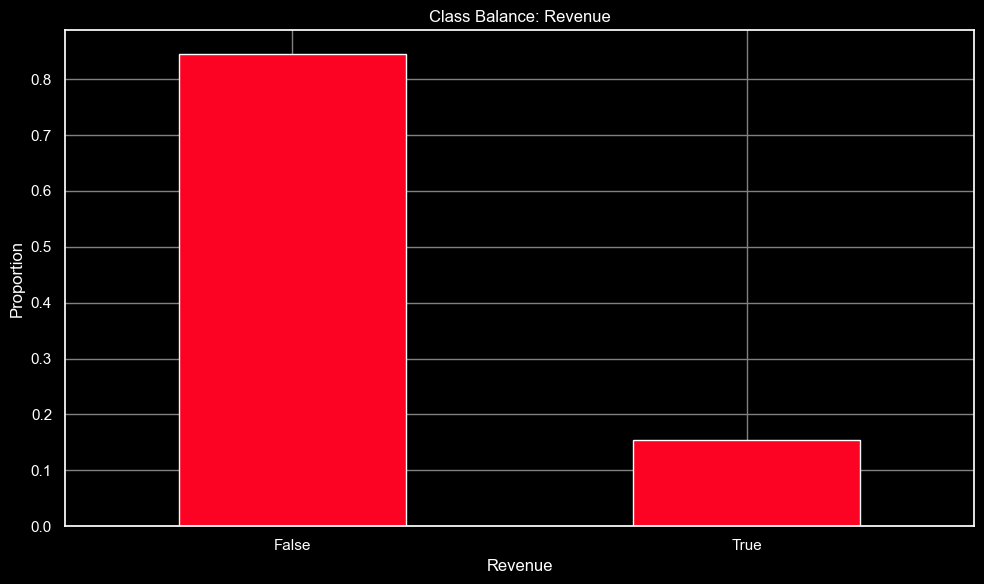


===== NUMERIC SUMMARY BY TARGET =====
        PageValues                       ExitRates                     BounceRates                      \
              mean     median        std      mean    median       std        mean    median       std   
Revenue                                                                                                  
False     1.975998   0.000000   9.072424  0.047378  0.028571  0.051231    0.025317  0.004255  0.051877   
True     27.264518  16.758134  35.191954  0.019555  0.016000  0.016463    0.005117  0.000000  0.012185   

        ProductRelated_Duration                           
                           mean      median          std  
Revenue                                                   
False               1069.987809   510.19000  1803.797757  
True                1876.209615  1109.90625  2312.214392  

[Interpretation] Large mean differences between classes suggest
these features have discriminative power for classification.
High std 

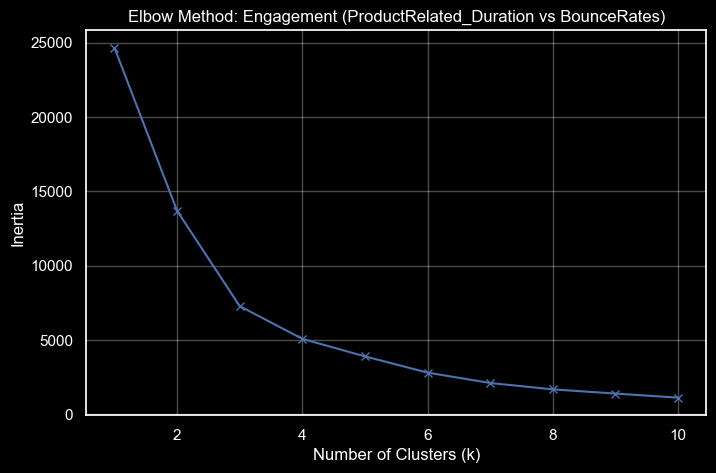

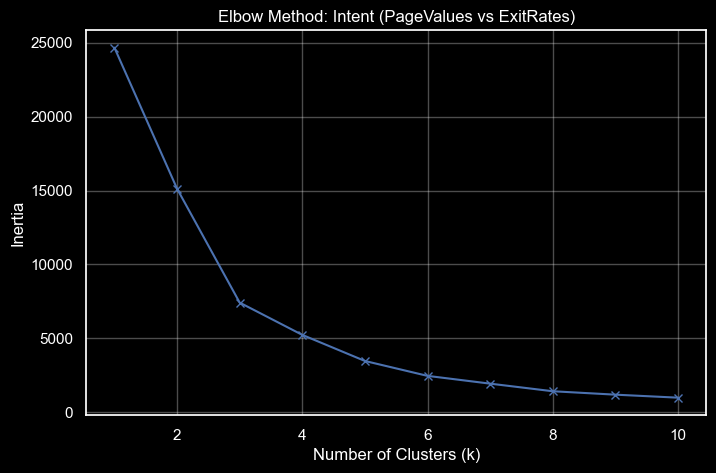

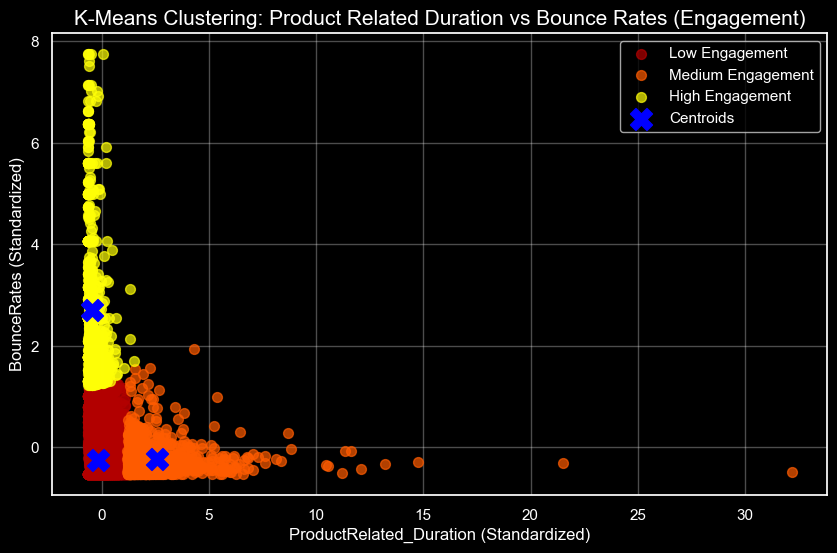

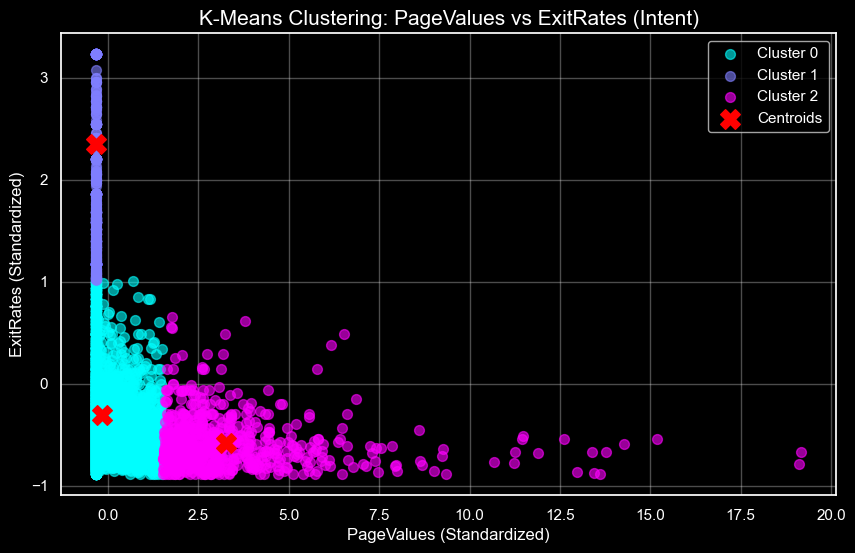


Train class balance BEFORE SMOTE: {0: 8338, 1: 1526}
Train class balance AFTER SMOTE: {0: 8338, 1: 8338}
Train size went from 9864 to 16676
Model trained
              precision    recall  f1-score   support

 No Purchase       0.94      0.89      0.92      2084
    Purchase       0.54      0.70      0.61       382

    accuracy                           0.86      2466
   macro avg       0.74      0.79      0.76      2466
weighted avg       0.88      0.86      0.87      2466

Accuracy:  0.8621
Precision: 0.5429
Recall:    0.6963
F1 Score:  0.6101
ROC AUC:   0.8657


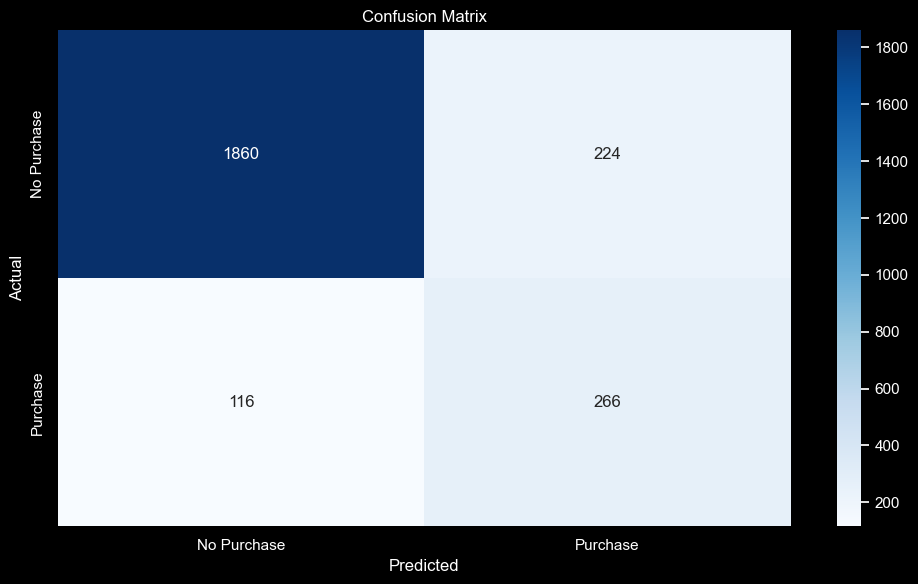

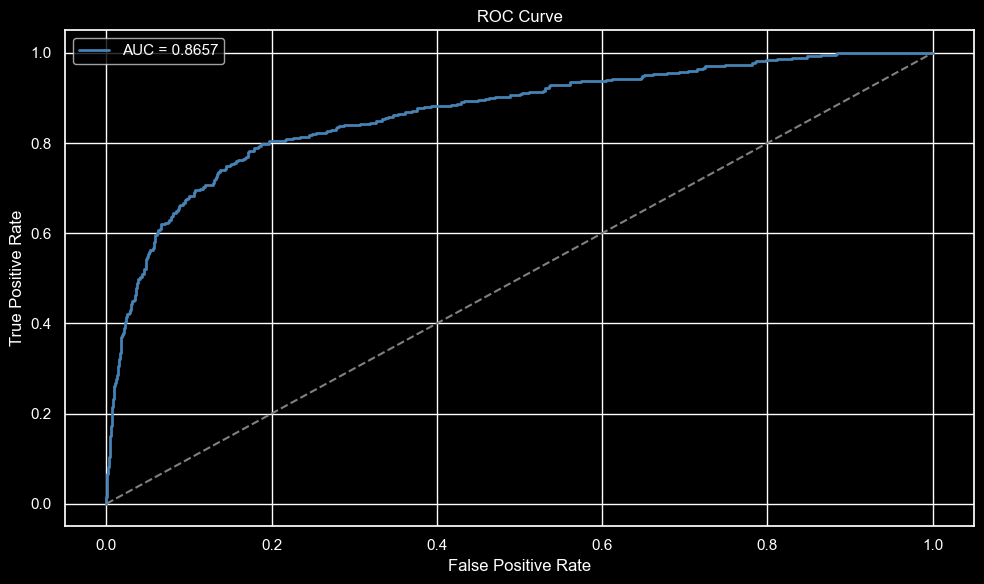

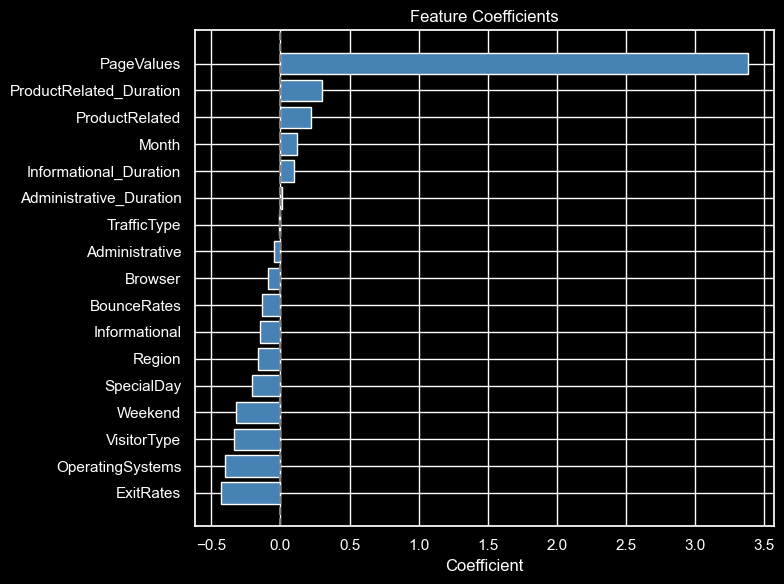


FEATURE TYPE SUMMARY
---------------------
Numerical features (6: ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues'])
Categorical features (11: ['Administrative', 'Informational', 'ProductRelated', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend'])


TRAIN/TEST SPLIT
----------------
X_train shape: (9864, 17)
X_test shape: (2466, 17)
y_train shape: (9864,)
y_test shape: (2466,)

Fitting 3 folds for each of 9 candidates, totalling 27 fits

HYPERPARAMETER TUNING
--------------------
Best parameters: {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best CV F1-Score: 0.642



MODEL PERFORMANCE ON TEST SET
----------------------------
ACCRUACY: 0.876
PRECISION: 0.577
RECALL: 0.738
F1-SCORE: 0.648
ROC-AUC: 0.909



    CONFUSION MATRIX:
[[1877  207]
 [ 100  282]]

    CLASSIFICATION REPORT:
                  precision    recall  f1-score   support

          

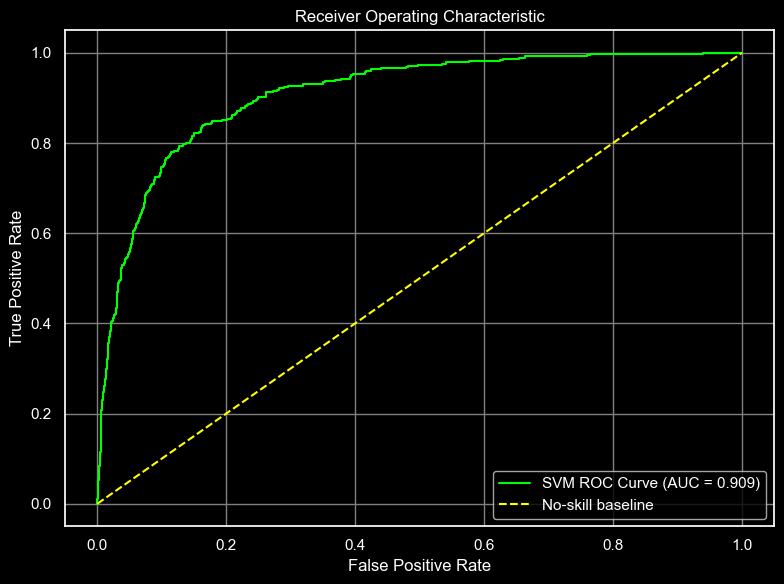

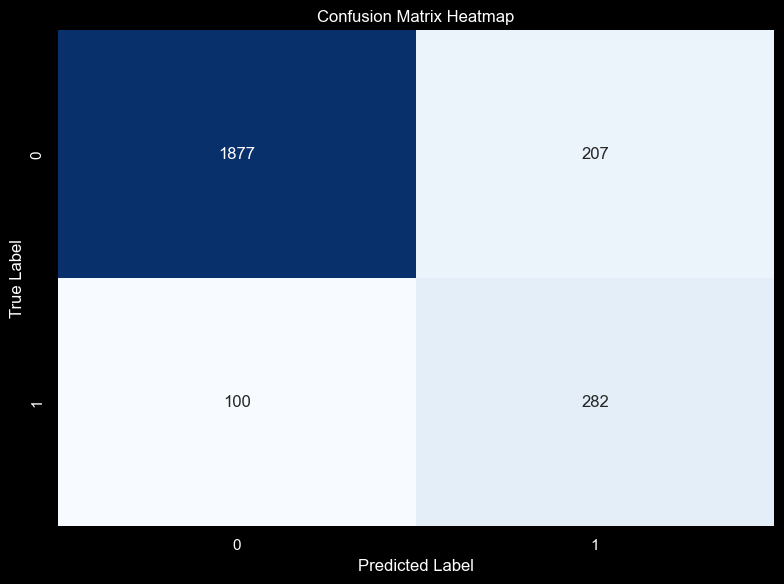

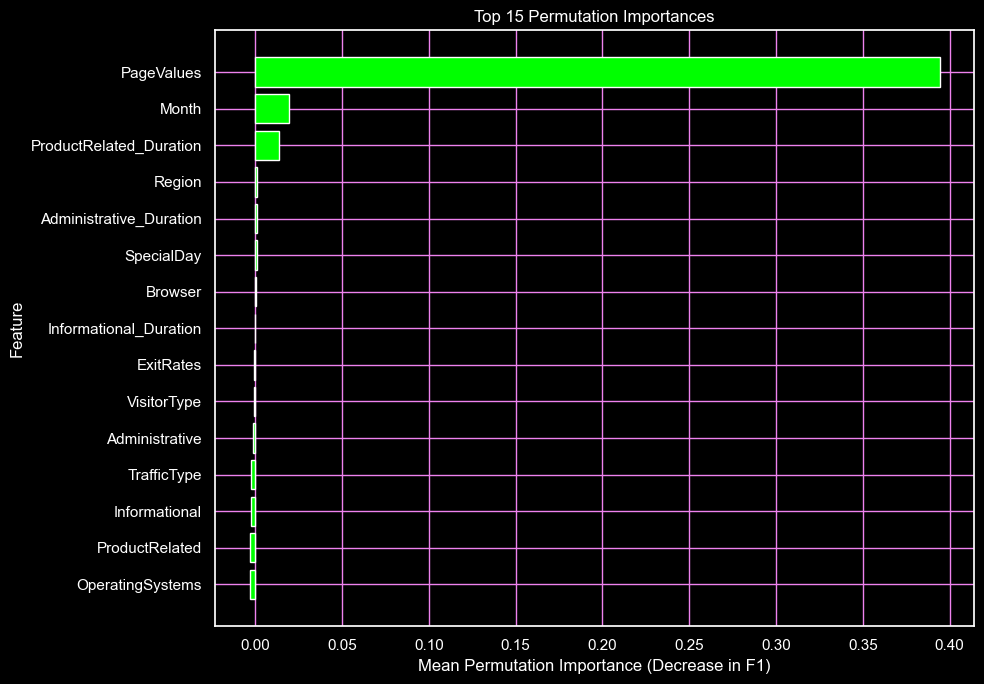


    TOP 15 PERMUTATION IMPORTANCES
    -----------------------------
                    feature  importance_mean  importance_std
             PageValues         0.394207        0.008609
                  Month         0.019600        0.007227
ProductRelated_Duration         0.013442        0.002399
                 Region         0.001271        0.002593
Administrative_Duration         0.000985        0.000411
             SpecialDay         0.000905        0.000753
                Browser         0.000477        0.001478
 Informational_Duration        -0.000069        0.001650
              ExitRates        -0.000674        0.004592
            VisitorType        -0.000931        0.000760
         Administrative        -0.001576        0.002934
            TrafficType        -0.002205        0.003167
          Informational        -0.002643        0.001577
         ProductRelated        -0.002907        0.003816
       OperatingSystems        -0.003269        0.001628



INTERPRETAT

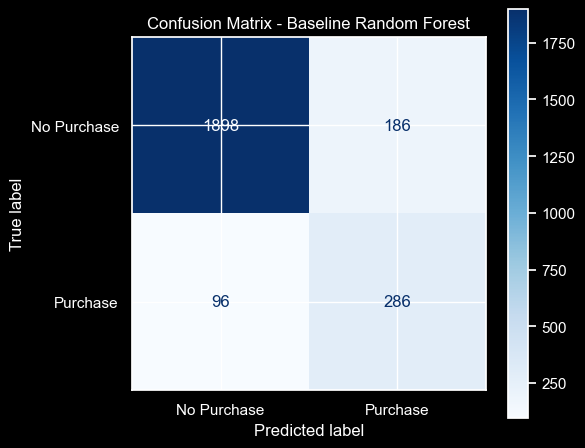

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation F1 Score: 0.9327

=== Tuned Random Forest Results ===
Accuracy:  0.8893
Precision: 0.6167
Recall:    0.7539
F1 Score:  0.6784
AUROC:     0.9184

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2084
           1       0.62      0.75      0.68       382

    accuracy                           0.89      2466
   macro avg       0.78      0.83      0.81      2466
weighted avg       0.90      0.89      0.89      2466



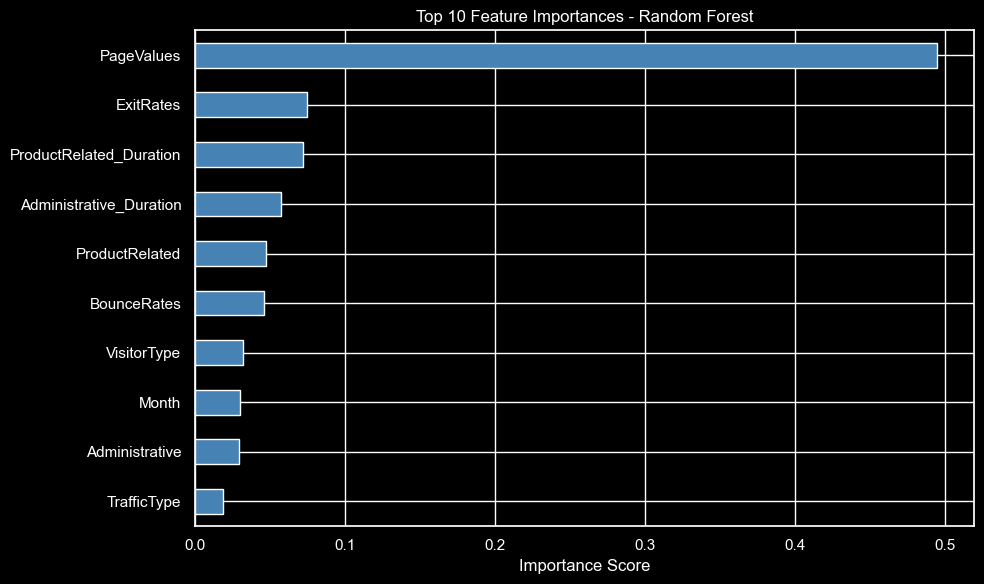


Top 10 Features:
PageValues                 0.494441
ExitRates                  0.075102
ProductRelated_Duration    0.072445
Administrative_Duration    0.057578
ProductRelated             0.047475
BounceRates                0.045960
VisitorType                0.032385
Month                      0.029975
Administrative             0.029649
TrafficType                0.019151
dtype: float64


/Users/whitney/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/whitney/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


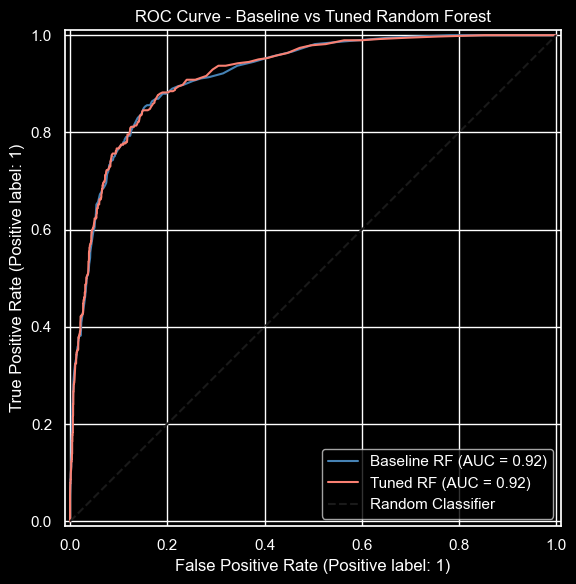

=== Random Forest Results Summary ===

=== Performance Goal Check (Tuned Model) ===
AUROC >= 0.80:     0.9184 --> PASS
F1 Score >= 0.70:  0.6784 --> BELOW TARGET
Recall >= 0.70:    0.7539 --> PASS


In [11]:
PATH = "../online_shoppers_intention.csv"
df = read_data(PATH)

wrangler = DataWrangling(df)

print("============== EDA ==============")

# Dataset overview
wrangler.dataset_overview()

# Column summary
summary = wrangler.column_summary()
print(summary)

# Convert datatypes
df, var_types = wrangler.convert_datatype()

# Target analysis
TARGET = "Revenue"
wrangler.target_info(TARGET)

# Baseline model
wrangler.baseline_accuracy(TARGET)

# Correlation with target
wrangler.target_correlation(TARGET)

# Compares distributions of selected numeric features via target class to
# see whether purchasers non-purchasers differ in central tendency and
# spread
wrangler.plot_target_balance(TARGET)

# Purchase probability: Revenue for the given month
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Bar charts since x-axis is categorical
wrangler.plot_category_rate("Month", TARGET, order=month_order)
wrangler.plot_category_rate("VisitorType", TARGET)
wrangler.plot_category_rate("Weekend", TARGET)

# Compares numeric features between target classes using grouped summary
# stats
wrangler.numeric_target_summary(
    ["PageValues", "ExitRates", "BounceRates", "ProductRelated_Duration"],
    TARGET
)

# ====== KMeans ========
run_kmeanz()

# ======== Logistic Regression =========
log_regression(df)

# ======== SVM ========
run_svm()

# ====== Random Forest ======
run_rf(df)

